In [1]:
!pip install -q xgboost imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
np.random.seed(42)
n = 20000

amount = np.round(np.random.lognormal(3.7, 0.9, n), 2)
hour = np.random.randint(0, 24, n)

merchant = np.random.choice(
    ["Grocery", "Electronics", "Travel", "Restaurant", "Online", "Fuel"],
    n,
    p=[.22, .14, .10, .20, .18, .16]
)

distance = np.round(np.random.exponential(18, n), 2)
previous = np.random.randint(1, 101, n)
avg_amount = np.round(np.random.lognormal(3.5, .65, n), 2)
device_trust = np.round(np.random.beta(5, 2, n), 2)
international = np.random.choice([0, 1], n, p=[.92, .08])
failed = np.random.poisson(.35, n)
account_age = np.random.randint(30, 3001, n)
velocity = np.random.poisson(2, n) + 1

score = (
    1.25 * (amount > 250) +
    1.30 * (distance > 50) +
    1.70 * (device_trust < .35) +
    1.25 * international +
    1.55 * (failed >= 2) +
    1.15 * (hour <= 4) +
    1.00 * (amount > 2.5 * avg_amount) +
    0.65 * (velocity >= 6) +
    0.30 * np.isin(merchant, ["Electronics", "Online"])
)

score += np.random.normal(0, 1.15, n)

fraud = (score >= np.quantile(score, .97)).astype(int)

df = pd.DataFrame({
    "transaction_id": np.arange(100001, 100001 + n),
    "transaction_amount": amount,
    "transaction_hour": hour,
    "merchant_category": merchant,
    "distance_from_home": distance,
    "previous_transactions": previous,
    "avg_transaction_amount": avg_amount,
    "device_trust_score": device_trust,
    "international_transaction": international,
    "failed_attempts": failed,
    "account_age_days": account_age,
    "transactions_last_24h": velocity,
    "fraud": fraud
})

df.to_csv("fraud_transactions.csv", index=False)

print("Dataset generated successfully!")
print("Shape:", df.shape)

Dataset generated successfully!
Shape: (20000, 13)


In [4]:
df.head()

,transaction_id,transaction_amount,transaction_hour,merchant_category,distance_from_home,previous_transactions,avg_transaction_amount,device_trust_score,international_transaction,failed_attempts,account_age_days,transactions_last_24h,fraud
0,100001,63.25,16,Online,22.55,38,27.57,0.76,0,0,1357,3,0
1,100002,35.71,17,Travel,22.61,45,13.29,0.87,1,2,2711,1,0
2,100003,72.45,3,Online,6.63,64,49.92,0.46,0,0,149,3,0
3,100004,159.29,2,Online,6.53,85,11.88,0.61,0,0,2092,3,0
4,100005,32.76,7,Fuel,6.96,54,83.97,0.95,1,0,2823,3,0


In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             20000 non-null  int64  
 1   transaction_amount         20000 non-null  float64
 2   transaction_hour           20000 non-null  int64  
 3   merchant_category          20000 non-null  object 
 4   distance_from_home         20000 non-null  float64
 5   previous_transactions      20000 non-null  int64  
 6   avg_transaction_amount     20000 non-null  float64
 7   device_trust_score         20000 non-null  float64
 8   international_transaction  20000 non-null  int64  
 9   failed_attempts            20000 non-null  int64  
 10  account_age_days           20000 non-null  int64  
 11  transactions_last_24h      20000 non-null  int64  
 12  fraud                      20000 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usag

,transaction_id,transaction_amount,transaction_hour,distance_from_home,previous_transactions,avg_transaction_amount,device_trust_score,international_transaction,failed_attempts,account_age_days,transactions_last_24h,fraud
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,110000.500000,61.123929,11.547200,17.893254,50.419900,41.170423,0.714584,0.077250,0.356500,1514.027800,2.994200,0.030000
std,5773.647028,69.862305,6.943269,17.684836,28.894694,29.855666,0.159809,0.266994,0.595336,862.089695,1.415615,0.170591
min,100001.000000,1.190000,0.000000,0.000000,1.000000,2.950000,0.110000,0.000000,0.000000,30.000000,1.000000,0.000000
25%,105000.750000,22.207500,6.000000,5.260000,26.000000,21.117500,0.610000,0.000000,0.000000,768.000000,2.000000,0.000000
50%,110000.500000,40.730000,11.000000,12.530000,50.000000,33.280000,0.740000,0.000000,0.000000,1511.000000,3.000000,0.000000
75%,115000.250000,74.720000,18.000000,24.982500,75.000000,51.520000,0.840000,0.000000,1.000000,2261.000000,4.000000,0.000000
max,120000.000000,2278.280000,23.000000,161.780000,100.000000,373.810000,1.000000,1.000000,5.000000,3000.000000,12.000000,1.000000


In [6]:
df["fraud"].value_counts()

,count
fraud,
0,19400
1,600


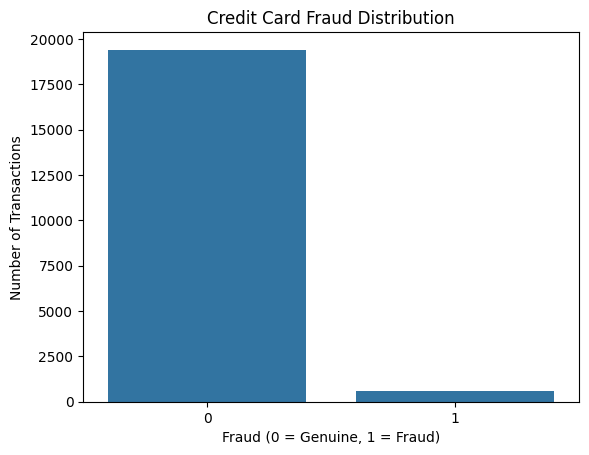

In [7]:
sns.countplot(x="fraud", data=df)

plt.title("Credit Card Fraud Distribution")
plt.xlabel("Fraud (0 = Genuine, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

In [8]:
X = df.drop(["fraud", "transaction_id"], axis=1)
y = df["fraud"]

print("Features:")
print(X.columns)

print("Target:")
print(y.name)

Features:
Index(['transaction_amount', 'transaction_hour', 'merchant_category',
       'distance_from_home', 'previous_transactions', 'avg_transaction_amount',
       'device_trust_score', 'international_transaction', 'failed_attempts',
       'account_age_days', 'transactions_last_24h'],
      dtype='object')
Target:
fraud


In [9]:
X.isnull().sum()

,0
transaction_amount,0
transaction_hour,0
merchant_category,0
distance_from_home,0
previous_transactions,0
avg_transaction_amount,0
device_trust_score,0
international_transaction,0
failed_attempts,0
account_age_days,0


In [10]:
print("Merchant Category:")
print(df["merchant_category"].value_counts())

print("\nFraud Percentage:")
print(df["fraud"].value_counts(normalize=True) * 100)

Merchant Category:
merchant_category
Grocery        4383
Restaurant     4032
Online         3580
Fuel           3209
Electronics    2851
Travel         1945
Name: count, dtype: int64

Fraud Percentage:
fraud
0    97.0
1     3.0
Name: proportion, dtype: float64


In [11]:
X_encoded = pd.get_dummies(
    X,
    columns=["merchant_category"],
    drop_first=True
)

X_encoded.head()

,transaction_amount,transaction_hour,distance_from_home,previous_transactions,avg_transaction_amount,device_trust_score,international_transaction,failed_attempts,account_age_days,transactions_last_24h,merchant_category_Fuel,merchant_category_Grocery,merchant_category_Online,merchant_category_Restaurant,merchant_category_Travel
0,63.25,16,22.55,38,27.57,0.76,0,0,1357,3,False,False,True,False,False
1,35.71,17,22.61,45,13.29,0.87,1,2,2711,1,False,False,False,False,True
2,72.45,3,6.63,64,49.92,0.46,0,0,149,3,False,False,True,False,False
3,159.29,2,6.53,85,11.88,0.61,0,0,2092,3,False,False,True,False,False
4,32.76,7,6.96,54,83.97,0.95,1,0,2823,3,True,False,False,False,False


In [12]:
print("Original number of features:", X.shape[1])
print("Encoded number of features:", X_encoded.shape[1])

Original number of features: 11
Encoded number of features: 15


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16000
Testing samples: 4000


In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

print("Before SMOTE:")
print(y_train.value_counts())

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
fraud
0    15520
1      480
Name: count, dtype: int64

After SMOTE:
fraud
0    15520
1    15520
Name: count, dtype: int64


In [15]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train_smote, y_train_smote)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [16]:
y_prob = model.predict_proba(X_test)[:, 1]

print(y_prob[:10])

[0.00717001 0.3477299  0.05273169 0.8561817  0.26989758 0.01299841
 0.01294385 0.01248442 0.13540216 0.09095477]


In [17]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc, 4))

ROC-AUC Score: 0.7684


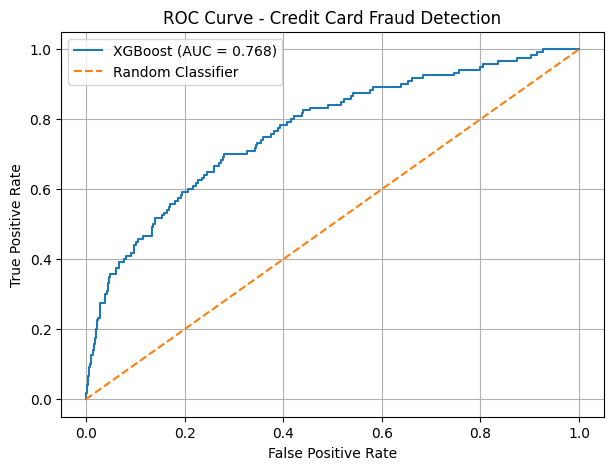

In [18]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Card Fraud Detection")
plt.legend()
plt.grid()

plt.show()

In [19]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

y_pred = (y_prob >= 0.5).astype(int)

print("Classification Report at Threshold 0.5:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Genuine", "Fraud"],
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Classification Report at Threshold 0.5:
              precision    recall  f1-score   support

     Genuine       0.98      0.92      0.95      3880
       Fraud       0.14      0.39      0.20       120

    accuracy                           0.91      4000
   macro avg       0.56      0.66      0.58      4000
weighted avg       0.95      0.91      0.93      4000

Confusion Matrix:
[[3585  295]
 [  73   47]]


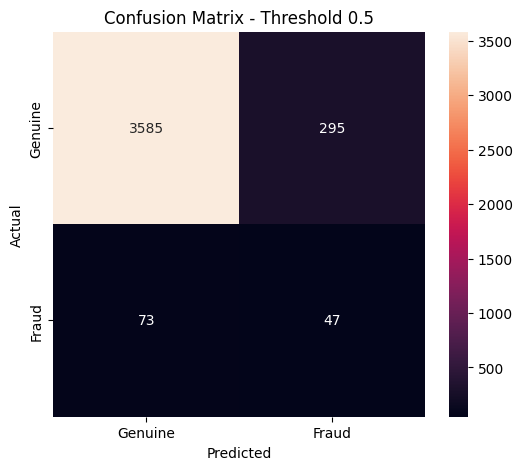

In [20]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Threshold 0.5")

plt.show()

In [21]:
thresholds_to_test = [0.5, 0.4, 0.3, 0.2, 0.1]

for threshold in thresholds_to_test:
    predictions = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    print(f"\nThreshold: {threshold}")
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-Score: {f1:.3f}")


Threshold: 0.5
TN: 3585, FP: 295, FN: 73, TP: 47
Precision: 0.137
Recall: 0.392
F1-Score: 0.203

Threshold: 0.4
TN: 3363, FP: 517, FN: 64, TP: 56
Precision: 0.098
Recall: 0.467
F1-Score: 0.162

Threshold: 0.3
TN: 3091, FP: 789, FN: 49, TP: 71
Precision: 0.083
Recall: 0.592
F1-Score: 0.145

Threshold: 0.2
TN: 2673, FP: 1207, FN: 36, TP: 84
Precision: 0.065
Recall: 0.700
F1-Score: 0.119

Threshold: 0.1
TN: 1959, FP: 1921, FN: 19, TP: 101
Precision: 0.050
Recall: 0.842
F1-Score: 0.094


In [22]:
threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    predictions = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": round(float(threshold), 2),
        "precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "f1_score": f1_score(
            y_test, predictions, zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

best_row = threshold_df.loc[
    threshold_df["f1_score"].idxmax()
]

best_threshold = float(best_row["threshold"])

print(threshold_df.round(4))
print("\nBest threshold:", best_threshold)

    threshold  precision  recall  f1_score
0        0.10     0.0500  0.8417    0.0943
1        0.15     0.0577  0.7750    0.1073
2        0.20     0.0651  0.7000    0.1191
3        0.25     0.0739  0.6500    0.1327
4        0.30     0.0826  0.5917    0.1449
5        0.35     0.0908  0.5333    0.1552
6        0.40     0.0977  0.4667    0.1616
7        0.45     0.1210  0.4417    0.1900
8        0.50     0.1374  0.3917    0.2035
9        0.55     0.1660  0.3583    0.2269
10       0.60     0.1875  0.3000    0.2308
11       0.65     0.2205  0.2333    0.2267
12       0.70     0.2169  0.1500    0.1773
13       0.75     0.2500  0.1083    0.1512
14       0.80     0.2500  0.0417    0.0714
15       0.85     0.3750  0.0250    0.0469
16       0.90     1.0000  0.0167    0.0328

Best threshold: 0.6


In [28]:
y_pred_tuned = (
    y_prob >= best_threshold
).astype(int)

print("Final Classification Report:")
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=["Genuine", "Fraud"],
    zero_division=0
))

cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned
)

print("Final Confusion Matrix:")
print(cm_tuned)

Final Classification Report:
              precision    recall  f1-score   support

     Genuine       0.98      0.96      0.97      3880
       Fraud       0.19      0.30      0.23       120

    accuracy                           0.94      4000
   macro avg       0.58      0.63      0.60      4000
weighted avg       0.95      0.94      0.95      4000

Final Confusion Matrix:
[[3724  156]
 [  84   36]]


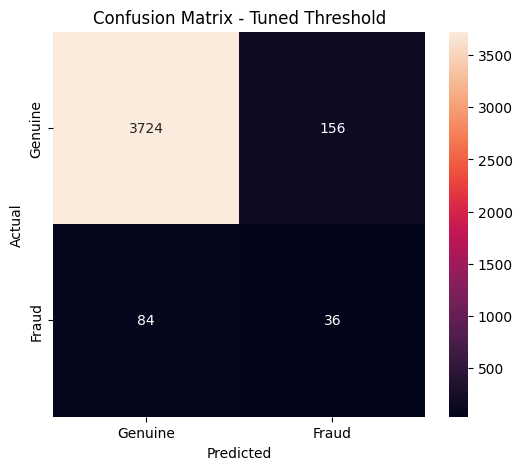

In [24]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Threshold")

plt.show()

In [25]:
importance_df = pd.DataFrame({
    "feature": X_encoded.columns,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("Top 10 Important Features:")
print(importance_df.head(10))

Top 10 Important Features:
                         feature  importance
1               transaction_hour    0.140866
12      merchant_category_Online    0.111606
13  merchant_category_Restaurant    0.105671
10        merchant_category_Fuel    0.103968
11     merchant_category_Grocery    0.099151
14      merchant_category_Travel    0.081820
0             transaction_amount    0.072273
5             device_trust_score    0.046976
2             distance_from_home    0.046289
6      international_transaction    0.042132


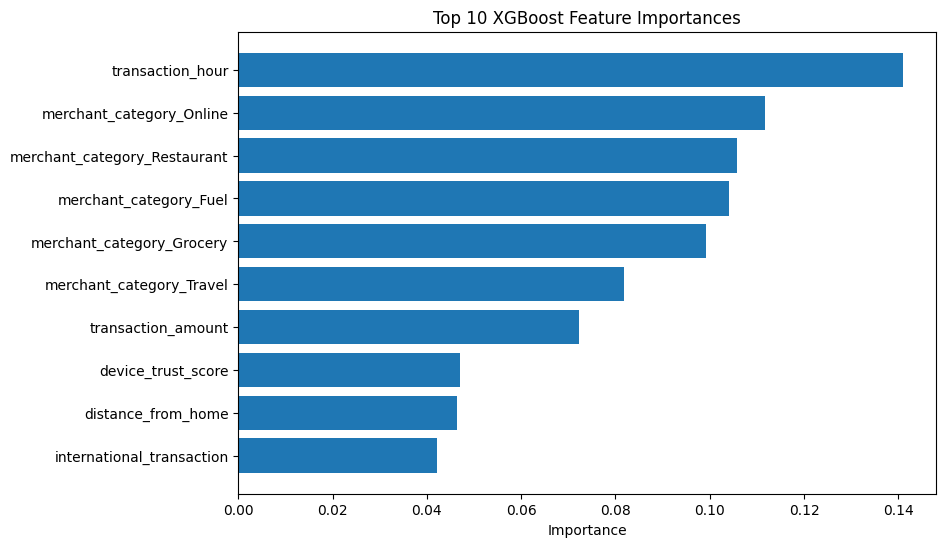

In [26]:
top = importance_df.head(10)

plt.figure(figsize=(9, 6))

plt.barh(
    top["feature"][::-1],
    top["importance"][::-1]
)

plt.xlabel("Importance")
plt.title("Top 10 XGBoost Feature Importances")

plt.show()

In [27]:
threshold_df.to_csv(
    "threshold_results.csv",
    index=False
)

importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


## Case Study 2: Credit Card Fraud Detection

### Objective
Predict whether a credit card transaction is genuine or fraudulent.

### Techniques Used
- XGBoost
- SMOTE for class imbalance
- Decision threshold tuning
- ROC-AUC
- Confusion Matrix
- Precision, Recall and F1-score
- Feature Importance

### False Positives vs False Negatives
- **False Positive:** A genuine transaction is incorrectly flagged as fraud. This may inconvenience a genuine customer.
- **False Negative:** A fraudulent transaction is incorrectly classified as genuine. This can cause direct financial loss.

In fraud detection, reducing false negatives is especially important, but lowering the threshold can increase false positives. Therefore, the decision threshold should be selected according to the business cost of each error.